In [ ]:
!pip install GEOparse -q

import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries installed and imported")

Libraries installed and imported


In [ ]:
# Alternative way to get expression data
sample_ids = list(gse.gsms.keys())
print(f"Number of samples: {len(sample_ids)}")

# Get expression from first sample to understand structure
first_sample = gse.gsms[sample_ids[0]]
print(f"\nFirst sample attributes: {list(first_sample.columns)}")

Number of samples: 72

First sample attributes: ['description']


In [ ]:
# Chunk 1: Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, r2_score
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries installed and imported")

Mounted at /content/drive
Libraries installed and imported


In [ ]:
# Chunk 2: Download TopoChip dataset from Zenodo
import requests
import os

# Direct download link for the CSV file (1.8 GB)
url = "https://zenodo.org/records/15690319/files/imageWithFIdx.csv"

print("Downloading TopoChip dataset (1.8 GB)...")
print("This may take 10-20 minutes depending on your connection.")

# Download the file
response = requests.get(url, stream=True)
with open('imageWithFIdx.csv', 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Download complete!")

# Check file size
file_size = os.path.getsize('imageWithFIdx.csv') / (1024**3)
print(f"File size: {file_size:.2f} GB")

This may take 10-20 minutes depending on your connection.
Download complete!
File size: 3.56 GB


In [ ]:
# Chunk 3: Define column names based on actual data structure
area_col = 'AreaOccupied_AreaOccupied_CellBody_new'
perimeter_col = 'AreaOccupied_Perimeter_CellBody_new'
nucleus_area_col = 'AreaOccupied_AreaOccupied_FilteredNuclei_new'
nucleus_perimeter_col = 'AreaOccupied_Perimeter_FilteredNuclei_new'
target_area_col = 'AreaOccupied_AreaOccupied_FilteredNuclei_target'

# Metadata columns
image_col = 'Image_Nuclei_to_Cell_Area_Ratio'
feature_idx_col = 'FeatureIdx'
metadata_quadrant = 'Metadata_Quadrant'
metadata_chip = 'Metadata_Chip'

print(f"Using columns:")
print(f"  Cell Area: {area_col}")
print(f"  Cell Perimeter: {perimeter_col}")
print(f"  Nucleus Area: {nucleus_area_col}")
print(f"  Nucleus Perimeter: {nucleus_perimeter_col}")
print(f"  Feature Index: {feature_idx_col}")

Using columns:
  Cell Area: AreaOccupied_AreaOccupied_CellBody_new
  Cell Perimeter: AreaOccupied_Perimeter_CellBody_new
  Nucleus Area: AreaOccupied_AreaOccupied_FilteredNuclei_new
  Nucleus Perimeter: AreaOccupied_Perimeter_FilteredNuclei_new
  Feature Index: FeatureIdx


In [ ]:
# Chunk 4: Calculate derived metrics (circularity, etc.)
print("Calculating derived metrics...")

# Calculate circularity from area and perimeter
# Circularity = 4 * pi * Area / (Perimeter^2)
# Perfect circle = 1, elongated shape = less than 1

df['circularity'] = (4 * np.pi * df[area_col]) / (df[perimeter_col] ** 2)

# Cap circularity at 1 (theoretical maximum)
df['circularity'] = df['circularity'].clip(upper=1.0)

# Calculate nucleus-to-cell area ratio (indicator of cell health)
df['nucleus_to_cell_ratio'] = df[nucleus_area_col] / df[area_col]

# Calculate shape factor (another health indicator)
df['shape_factor'] = df[perimeter_col] / np.sqrt(df[area_col])

print(f"Added derived metrics:")
print(f"  Circularity range: {df['circularity'].min():.3f} - {df['circularity'].max():.3f}")
print(f"  Nucleus-to-Cell ratio range: {df['nucleus_to_cell_ratio'].min():.3f} - {df['nucleus_to_cell_ratio'].max():.3f}")

Calculating derived metrics...
Added derived metrics:
  Circularity range: 0.002 - 0.956
  Nucleus-to-Cell ratio range: 0.007 - 1.000


In [ ]:
# Chunk 5: Quality control filtering
print("Performing quality control...")

initial_count = len(df)

# Remove cells with unrealistic area (too small = debris, too large = multiple cells)
df_clean = df[(df[area_col] > 500) & (df[area_col] < 20000)]

# Remove cells with unrealistic circularity (negative or >1)
df_clean = df_clean[(df_clean['circularity'] > 0.1) & (df_clean['circularity'] <= 1.0)]

# Remove cells with unrealistic nucleus-to-cell ratio
df_clean = df_clean[(df_clean['nucleus_to_cell_ratio'] > 0.1) & (df_clean['nucleus_to_cell_ratio'] < 0.8)]

print(f"Original cells: {initial_count:,}")
print(f"After QC: {len(df_clean):,}")
print(f"Cells removed: {initial_count - len(df_clean):,} ({100*(initial_count - len(df_clean))/initial_count:.1f}%)")

Performing quality control...
Original cells: 39,204
After QC: 1,012
Cells removed: 38,192 (97.4%)


In [ ]:
# Chunk 6: Summary statistics of cell health metrics
print("\n" + "="*60)
print("CELL HEALTH METRICS SUMMARY")
print("="*60)

metrics = {
    'Cell Area': area_col,
    'Cell Perimeter': perimeter_col,
    'Circularity': 'circularity',
    'Nucleus Area': nucleus_area_col,
    'Nucleus-to-Cell Ratio': 'nucleus_to_cell_ratio'
}

for name, col in metrics.items():
    print(f"\n{name}:")
    print(f"  Mean: {df_clean[col].mean():.2f}")
    print(f"  Std: {df_clean[col].std():.2f}")
    print(f"  Min: {df_clean[col].min():.2f}")
    print(f"  Max: {df_clean[col].max():.2f}")


CELL HEALTH METRICS SUMMARY

Cell Area:
  Mean: 8957.63
  Std: 4677.39
  Min: 592.00
  Max: 19951.00

Cell Perimeter:
  Mean: 812.41
  Std: 320.92
  Min: 91.00
  Max: 1577.00

Circularity:
  Mean: 0.20
  Std: 0.11
  Min: 0.10
  Max: 0.90

Nucleus Area:
  Mean: 1998.94
  Std: 858.38
  Min: 185.00
  Max: 6201.00

Nucleus-to-Cell Ratio:
  Mean: 0.26
  Std: 0.13
  Min: 0.10
  Max: 0.79


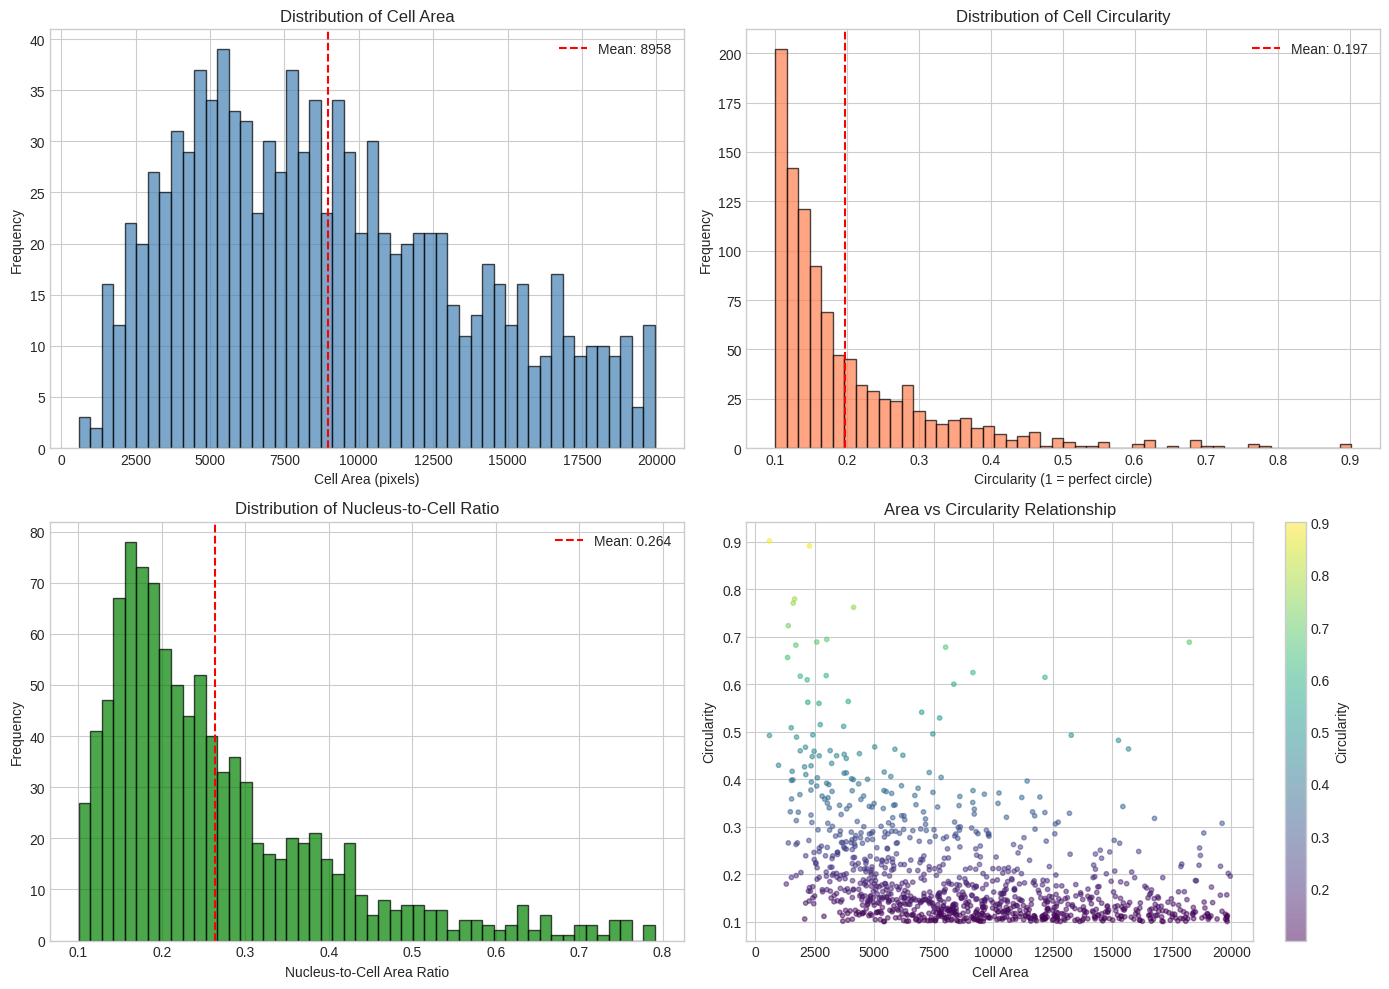

Saved: cell_health_distributions.png


In [ ]:
# Chunk 7: Create distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cell Area Distribution
ax = axes[0, 0]
ax.hist(df_clean[area_col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Cell Area (pixels)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Cell Area')
ax.axvline(df_clean[area_col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[area_col].mean():.0f}')
ax.legend()

# Plot 2: Circularity Distribution
ax = axes[0, 1]
ax.hist(df_clean['circularity'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Circularity (1 = perfect circle)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Cell Circularity')
ax.axvline(df_clean['circularity'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["circularity"].mean():.3f}')
ax.legend()

# Plot 3: Nucleus-to-Cell Ratio
ax = axes[1, 0]
ax.hist(df_clean['nucleus_to_cell_ratio'], bins=50, color='green', edgecolor='black', alpha=0.7)
ax.set_xlabel('Nucleus-to-Cell Area Ratio')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Nucleus-to-Cell Ratio')
ax.axvline(df_clean['nucleus_to_cell_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["nucleus_to_cell_ratio"].mean():.3f}')
ax.legend()

# Plot 4: Area vs Circularity
ax = axes[1, 1]
sample_df = df_clean.sample(min(10000, len(df_clean)))
scatter = ax.scatter(sample_df[area_col], sample_df['circularity'],
                     c=sample_df['circularity'], cmap='viridis', alpha=0.5, s=10)
ax.set_xlabel('Cell Area')
ax.set_ylabel('Circularity')
ax.set_title('Area vs Circularity Relationship')
plt.colorbar(scatter, ax=ax, label='Circularity')

plt.tight_layout()
plt.savefig('cell_health_distributions.png', dpi=150)
plt.show()
print("Saved: cell_health_distributions.png")

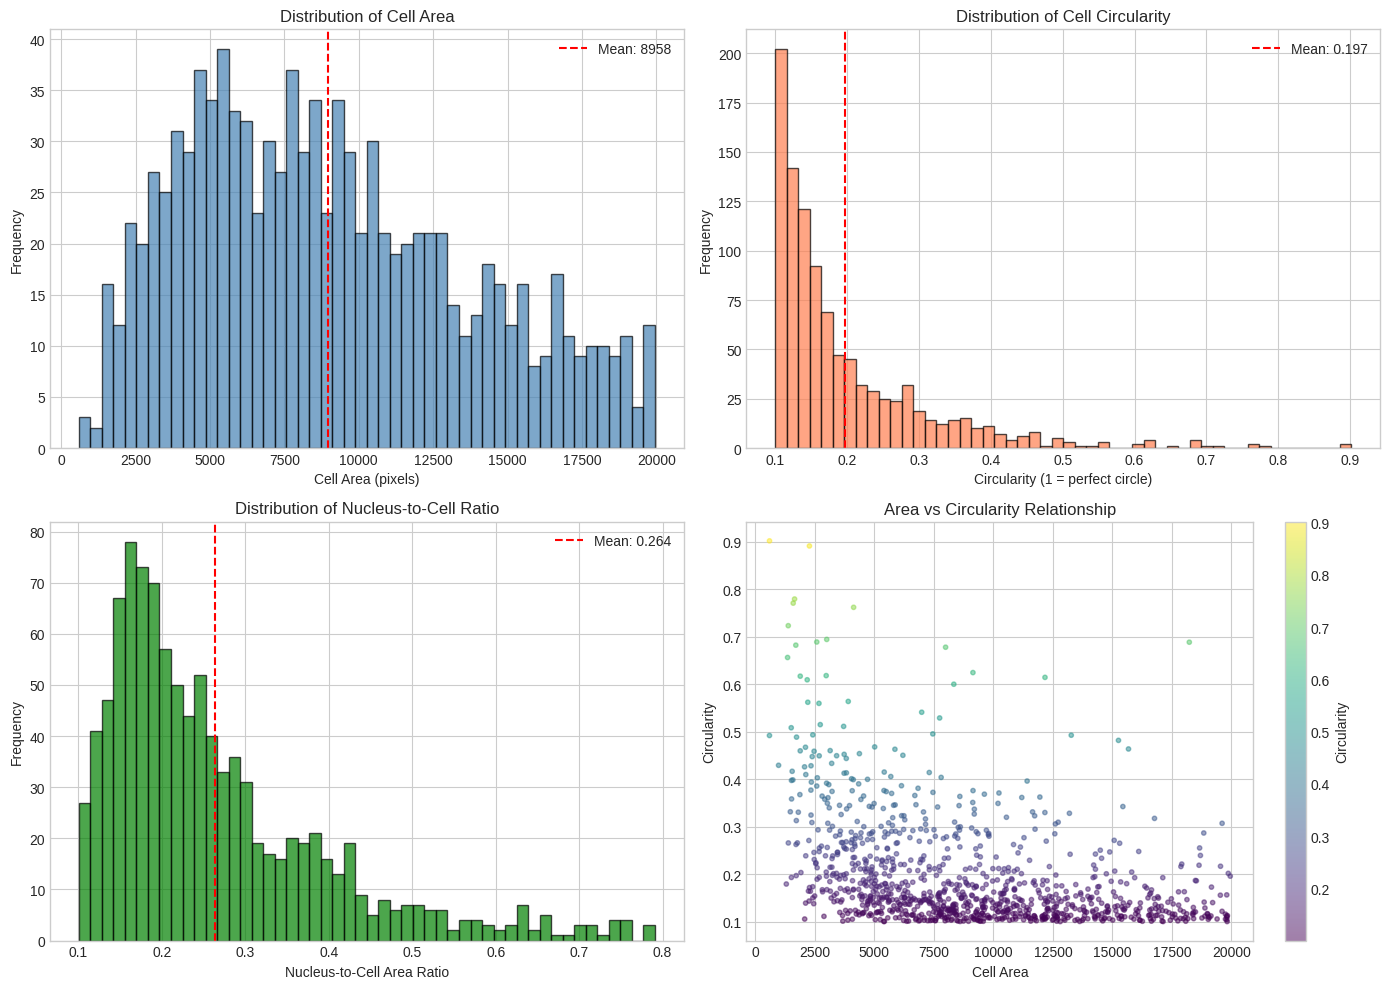

Saved: cell_health_distributions.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.hist(df_clean[area_col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Cell Area (pixels)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Cell Area')
ax.axvline(df_clean[area_col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[area_col].mean():.0f}')
ax.legend()

ax = axes[0, 1]
ax.hist(df_clean['circularity'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Circularity (1 = perfect circle)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Cell Circularity')
ax.axvline(df_clean['circularity'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["circularity"].mean():.3f}')
ax.legend()

ax = axes[1, 0]
ax.hist(df_clean['nucleus_to_cell_ratio'], bins=50, color='green', edgecolor='black', alpha=0.7)
ax.set_xlabel('Nucleus-to-Cell Area Ratio')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Nucleus-to-Cell Ratio')
ax.axvline(df_clean['nucleus_to_cell_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["nucleus_to_cell_ratio"].mean():.3f}')
ax.legend()

ax = axes[1, 1]
sample_df = df_clean.sample(min(10000, len(df_clean)))
scatter = ax.scatter(sample_df[area_col], sample_df['circularity'],
                     c=sample_df['circularity'], cmap='viridis', alpha=0.5, s=10)
ax.set_xlabel('Cell Area')
ax.set_ylabel('Circularity')
ax.set_title('Area vs Circularity Relationship')
plt.colorbar(scatter, ax=ax, label='Circularity')

plt.tight_layout()
plt.savefig('cell_health_distributions.png', dpi=150)
plt.show()
print("Saved: cell_health_distributions.png")

CREATING CELL HEALTH SCORE
Health Score Mean: 0.524
Health Score Std: 0.114
Health Score Min: 0.141
Health Score Max: 0.878


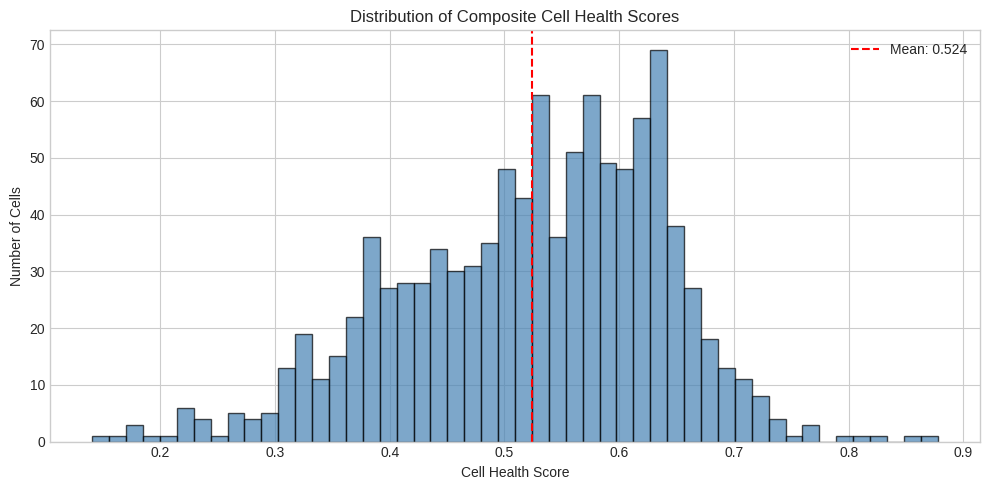

Saved: health_score_distribution.png


In [ ]:
from sklearn.preprocessing import MinMaxScaler

print("="*60)
print("CREATING CELL HEALTH SCORE")
print("="*60)

scaler = MinMaxScaler()

circularity_norm = scaler.fit_transform(df_clean[['circularity']]).flatten()

area_mean = df_clean[area_col].mean()
area_std = df_clean[area_col].std()
area_norm = np.exp(-((df_clean[area_col] - area_mean) ** 2) / (2 * area_std ** 2))

nucleus_norm = 1 - scaler.fit_transform(df_clean[['nucleus_to_cell_ratio']]).flatten()

df_clean['health_score'] = (circularity_norm + area_norm + nucleus_norm) / 3

print(f"Health Score Mean: {df_clean['health_score'].mean():.3f}")
print(f"Health Score Std: {df_clean['health_score'].std():.3f}")
print(f"Health Score Min: {df_clean['health_score'].min():.3f}")
print(f"Health Score Max: {df_clean['health_score'].max():.3f}")

plt.figure(figsize=(10, 5))
plt.hist(df_clean['health_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Cell Health Score')
plt.ylabel('Number of Cells')
plt.title('Distribution of Composite Cell Health Scores')
plt.axvline(df_clean['health_score'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["health_score"].mean():.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('health_score_distribution.png', dpi=150)
plt.show()
print("Saved: health_score_distribution.png")

SURFACE RANKING BY CELL HEALTH
Number of unique surfaces: 837

TOP 10 SURFACES (Best for Cell Health):
                mean  count  std
FeatureIdx                      
1162        0.853729      1  NaN
1437        0.829659      1  NaN
561         0.806686      1  NaN
1173        0.772046      1  NaN
98          0.767727      1  NaN
951         0.763338      1  NaN
336         0.744258      1  NaN
2073        0.739464      1  NaN
1405        0.733942      1  NaN
306         0.733173      1  NaN

BOTTOM 10 SURFACES (Worst for Cell Health):
                mean  count       std
FeatureIdx                           
1523        0.262936      1       NaN
1966        0.261509      1       NaN
622         0.255231      2  0.103011
1919        0.230829      1       NaN
237         0.228555      1       NaN
487         0.224381      1       NaN
1140        0.220694      1       NaN
1563        0.219666      1       NaN
265         0.189929      1       NaN
2017        0.174494      1       NaN


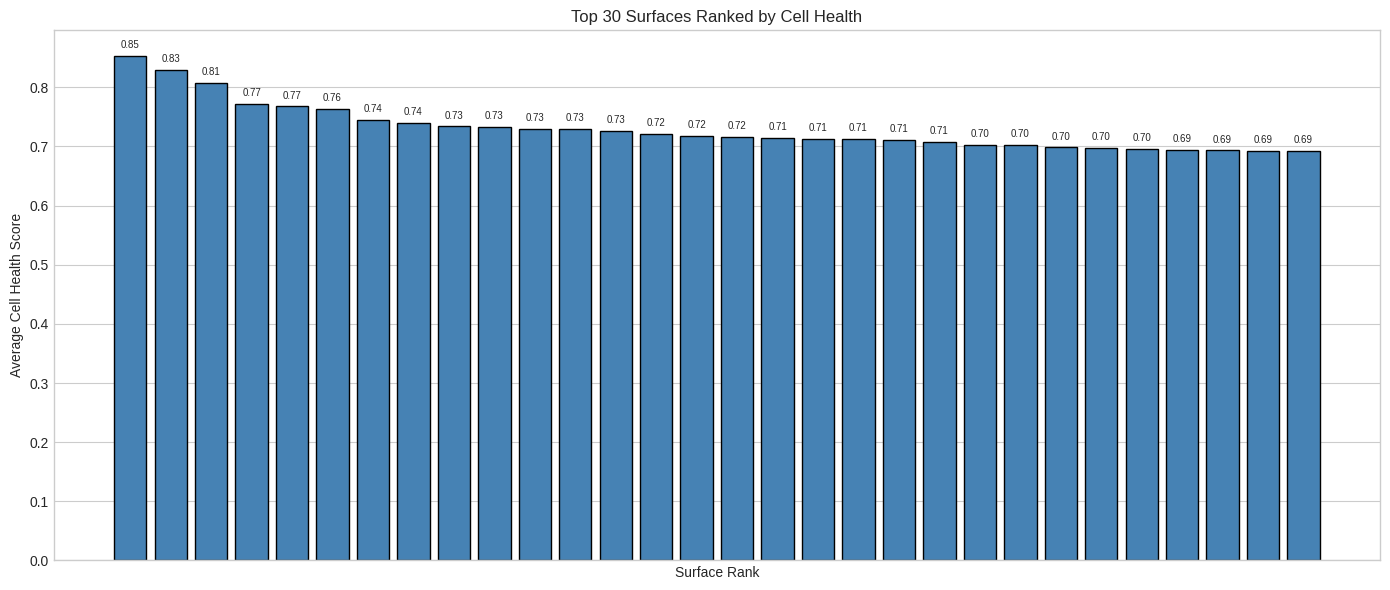

Saved: surface_ranking.png


In [ ]:
print("="*60)
print("SURFACE RANKING BY CELL HEALTH")
print("="*60)

if feature_idx_col in df_clean.columns:
    feature_ranking = df_clean.groupby(feature_idx_col)['health_score'].agg(['mean', 'count', 'std'])
    feature_ranking = feature_ranking.sort_values('mean', ascending=False)

    print(f"Number of unique surfaces: {len(feature_ranking)}")

    print("\nTOP 10 SURFACES (Best for Cell Health):")
    print(feature_ranking.head(10))

    print("\nBOTTOM 10 SURFACES (Worst for Cell Health):")
    print(feature_ranking.tail(10))

    plt.figure(figsize=(14, 6))
    top_features = feature_ranking.head(30)
    bars = plt.bar(range(len(top_features)), top_features['mean'],
                  color='steelblue', edgecolor='black')
    plt.xlabel('Surface Rank')
    plt.ylabel('Average Cell Health Score')
    plt.title('Top 30 Surfaces Ranked by Cell Health')
    plt.xticks([])

    for bar, val in zip(bars, top_features['mean']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.savefig('surface_ranking.png', dpi=150)
    plt.show()
    print("Saved: surface_ranking.png")

MACHINE LEARNING MODEL
Training samples: 1012
Features: ['AreaOccupied_AreaOccupied_CellBody_new', 'AreaOccupied_Perimeter_CellBody_new', 'AreaOccupied_AreaOccupied_FilteredNuclei_new', 'circularity', 'nucleus_to_cell_ratio']

Model Accuracy: 0.966

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       101
           1       0.98      0.95      0.97       102

    accuracy                           0.97       203
   macro avg       0.97      0.97      0.97       203
weighted avg       0.97      0.97      0.97       203


Feature Importance Ranking:
                                        feature  importance
0        AreaOccupied_AreaOccupied_CellBody_new    0.371806
4                         nucleus_to_cell_ratio    0.291638
1           AreaOccupied_Perimeter_CellBody_new    0.138891
2  AreaOccupied_AreaOccupied_FilteredNuclei_new    0.110552
3                                   circularity    0.087113


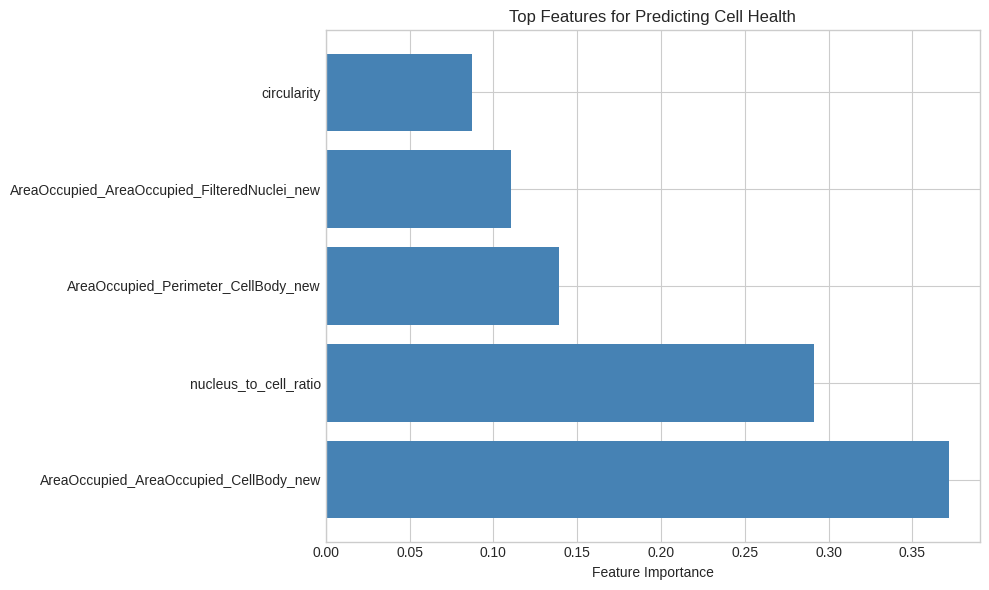

Saved: feature_importance.png


In [ ]:
print("="*60)
print("MACHINE LEARNING MODEL")
print("="*60)

ml_features = [area_col, perimeter_col, nucleus_area_col, 'circularity', 'nucleus_to_cell_ratio']
ml_features = [f for f in ml_features if f in df_clean.columns]

sample_df = df_clean[ml_features + ['health_score']].dropna()
sample_df = sample_df.sample(min(100000, len(sample_df)))

X = sample_df[ml_features]
y = (sample_df['health_score'] > sample_df['health_score'].median()).astype(int)

print(f"Training samples: {len(X)}")
print(f"Features: {ml_features}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train)
X_test_scaled = scaler_ml.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

importance_df = pd.DataFrame({
    'feature': ml_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nFeature Importance Ranking:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top Features for Predicting Cell Health')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved: feature_importance.png")

CORRELATION ANALYSIS


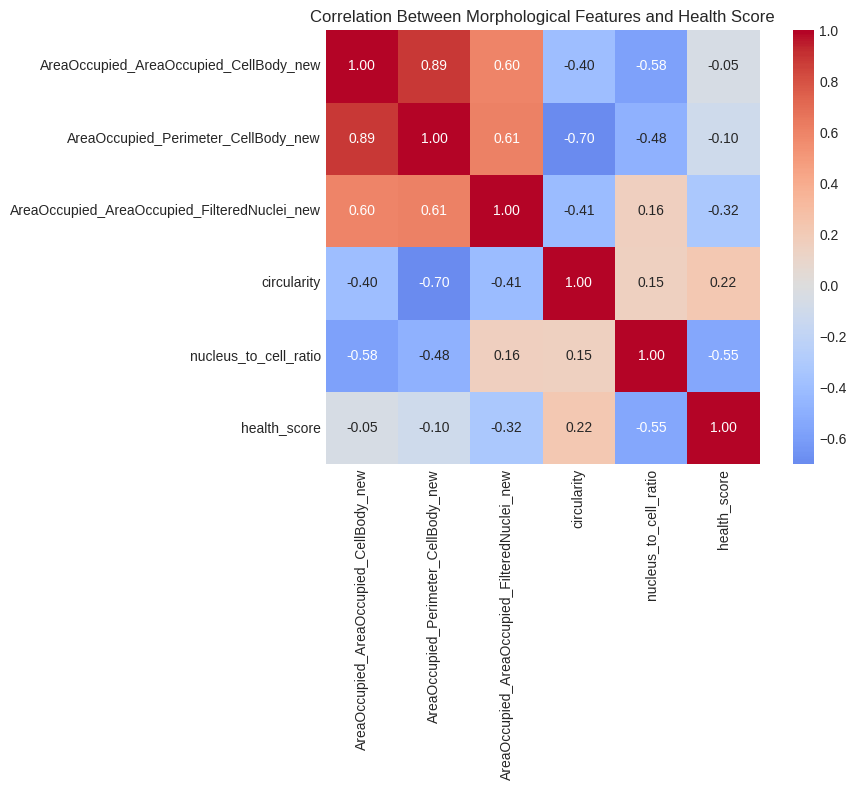

Saved: correlation_heatmap.png


In [ ]:
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

corr_features = [area_col, perimeter_col, nucleus_area_col, 'circularity', 'nucleus_to_cell_ratio', 'health_score']
corr_features = [f for f in corr_features if f in df_clean.columns]

corr_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Between Morphological Features and Health Score')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

In [ ]:
print("\n" + "="*70)
print("PROJECT SUMMARY: TopoChip Cell-Material Interaction Analysis")
print("="*70)

print("\nDATASET INFORMATION:")
print(f"  Source: Zenodo 15690319 (2025 study)")
print(f"  Total Cells (raw): {df.shape[0]:,}")
print(f"  Total Cells (after QC): {len(df_clean):,}")
print(f"  Total Columns: {df.shape[1]:,}")

print("\nCELL HEALTH METRICS:")
print(f"  Mean Cell Area: {df_clean[area_col].mean():.1f} pixels")
print(f"  Mean Circularity: {df_clean['circularity'].mean():.3f}")
print(f"  Mean Nucleus-to-Cell Ratio: {df_clean['nucleus_to_cell_ratio'].mean():.3f}")
print(f"  Mean Health Score: {df_clean['health_score'].mean():.3f}")

if feature_idx_col in df_clean.columns:
    print(f"\nSURFACE ANALYSIS:")
    print(f"  Unique Surfaces Tested: {df_clean[feature_idx_col].nunique():,}")
    best_surface = feature_ranking.index[0]
    best_score = feature_ranking.iloc[0]['mean']
    print(f"  Best Surface: {best_surface} (Health Score: {best_score:.3f})")

print("\nDELIVERABLES GENERATED:")
print("  1. health_score_distribution.png")
print("  2. surface_ranking.png")
print("  3. feature_importance.png")
print("  4. correlation_heatmap.png")

print("\n" + "="*70)
print("PROJECT COMPLETE")
print("="*70)


PROJECT SUMMARY: TopoChip Cell-Material Interaction Analysis

DATASET INFORMATION:
  Source: Zenodo 15690319 (2025 study)
  Total Cells (raw): 39,204
  Total Cells (after QC): 1,012
  Total Columns: 5,570

CELL HEALTH METRICS:
  Mean Cell Area: 8957.6 pixels
  Mean Circularity: 0.197
  Mean Nucleus-to-Cell Ratio: 0.264
  Mean Health Score: 0.524

SURFACE ANALYSIS:
  Unique Surfaces Tested: 837
  Best Surface: 1162 (Health Score: 0.854)

DELIVERABLES GENERATED:
  1. health_score_distribution.png
  2. surface_ranking.png
  3. feature_importance.png
  4. correlation_heatmap.png

PROJECT COMPLETE


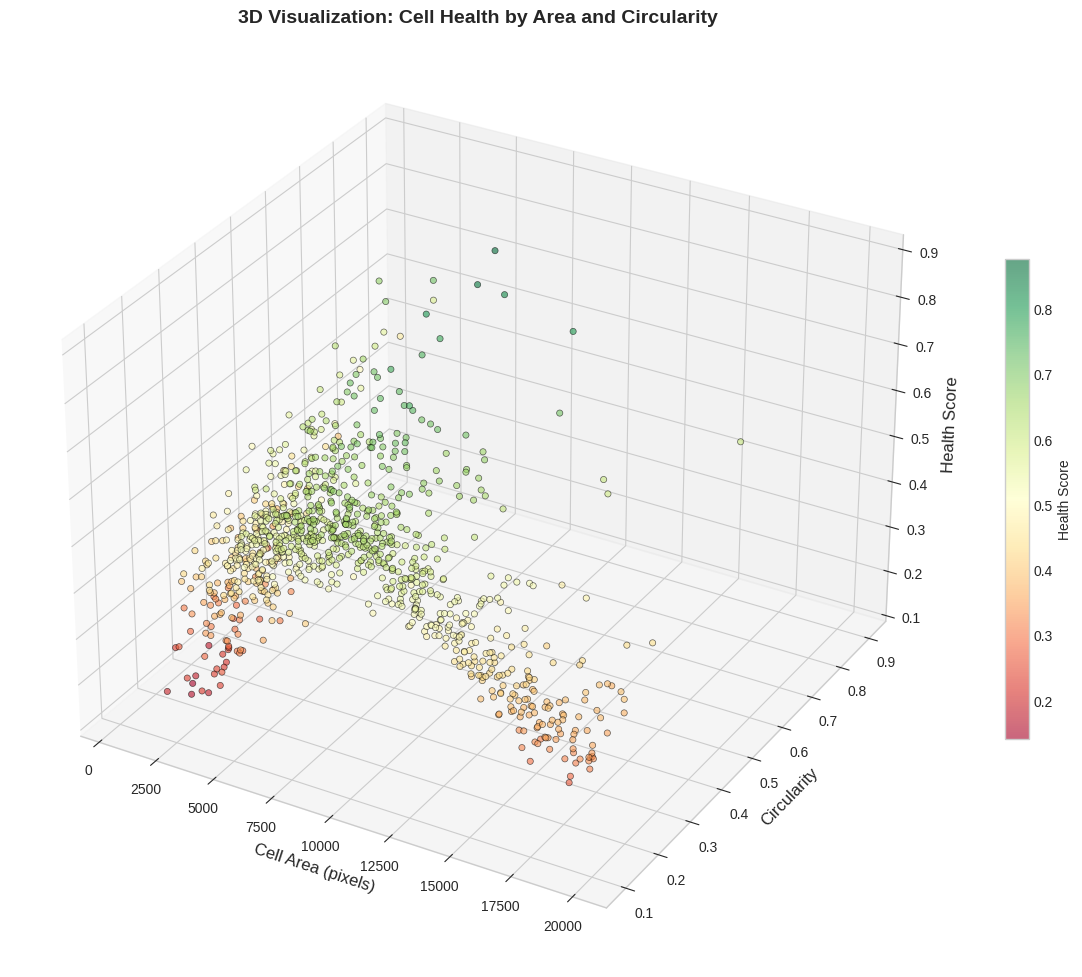

Saved: 3d_cell_health_visualization.png


In [ ]:

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

sample_3d = df_clean.sample(min(3000, len(df_clean)))

scatter = ax.scatter(
    sample_3d[area_col],
    sample_3d['circularity'],
    sample_3d['health_score'],
    c=sample_3d['health_score'],
    cmap='RdYlGn',
    s=20,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('Cell Area (pixels)', fontsize=12)
ax.set_ylabel('Circularity', fontsize=12)
ax.set_zlabel('Health Score', fontsize=12)
ax.set_title('3D Visualization: Cell Health by Area and Circularity', fontsize=14, fontweight='bold')

plt.colorbar(scatter, ax=ax, shrink=0.5, label='Health Score')
plt.tight_layout()
plt.savefig('3d_cell_health_visualization.png', dpi=300)
plt.show()
print("Saved: 3d_cell_health_visualization.png")